<h1>DENGUE DATA ANALYTICS ACTIVITY</h1>

<h1>ANALYST: JOHN PAUL U. NAYNES</h1>

In [4]:
import pandas as pd
import numpy as np
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
import folium
from folium.plugins import HeatMap
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('data_sets//dengue.csv')

In [6]:
df

,Month,Year,Region,Dengue_Cases,Dengue_Deaths
0,January,2016,Region I,705,1
1,February,2016,Region I,374,0
2,March,2016,Region I,276,0
3,April,2016,Region I,240,2
4,May,2016,Region I,243,1
...,...,...,...,...,...
1015,August,2020,BARMM,91,0
1016,September,2020,BARMM,16,8
1017,October,2020,BARMM,13,9
1018,November,2020,BARMM,15,1


In [7]:
df.describe()

,Year,Dengue_Cases,Dengue_Deaths
count,1020.000000,1020.000000,1020.000000
mean,2018.000000,1124.926471,16.513725
std,1.414907,1662.608878,96.358215
min,2016.000000,10.000000,0.000000
25%,2017.000000,247.750000,1.000000
50%,2018.000000,582.500000,3.000000
75%,2019.000000,1284.250000,7.000000
max,2020.000000,21658.000000,1651.000000


In [9]:
df.isnull()

,Month,Year,Region,Dengue_Cases,Dengue_Deaths
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
1015,False,False,False,False,False
1016,False,False,False,False,False
1017,False,False,False,False,False
1018,False,False,False,False,False


In [10]:
df.isnull().sum()

Month            0
Year             0
Region           0
Dengue_Cases     0
Dengue_Deaths    0
dtype: int64

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Month          1020 non-null   object
 1   Year           1020 non-null   int64 
 2   Region         1020 non-null   object
 3   Dengue_Cases   1020 non-null   int64 
 4   Dengue_Deaths  1020 non-null   int64 
dtypes: int64(3), object(2)
memory usage: 40.0+ KB


In [12]:
df.dtypes

Month            object
Year              int64
Region           object
Dengue_Cases      int64
Dengue_Deaths     int64
dtype: object

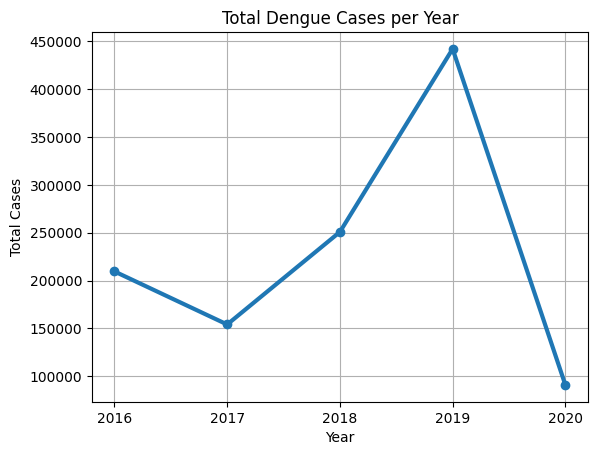

In [38]:
yearly_cases = df.groupby('Year')['Dengue_Cases'].sum()
plt.plot(yearly_cases.index, yearly_cases.values, marker='o', linewidth=3)
plt.title('Total Dengue Cases per Year')
plt.xlabel('Year')
plt.ylabel('Total Cases')
plt.grid(True)
plt.xticks([2016, 2017, 2018, 2019, 2020])
plt.show()

<h2>Insight 1: Dengue cases showed a steady increase from 2016 to 2019. However, there was a noticeable drop in 2020, possibly due to pandemic restrictions and better disease control.</h2>

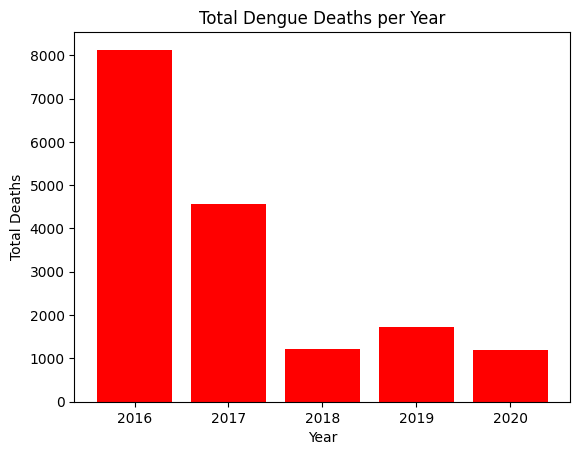

In [47]:
yearly_deaths = df.groupby('Year')['Dengue_Deaths'].sum()
plt.bar(yearly_deaths.index, yearly_deaths.values, color='red')
plt.title('Total Dengue Deaths per Year')
plt.xlabel('Year')
plt.ylabel('Total Deaths')
plt.show()

<h2>Insight 2: Dengue deaths followed the same pattern as total cases, with the highest deaths in 2019. The decline in 2020 suggests successful mitigation efforts or underreporting due to the pandemic.</h2>

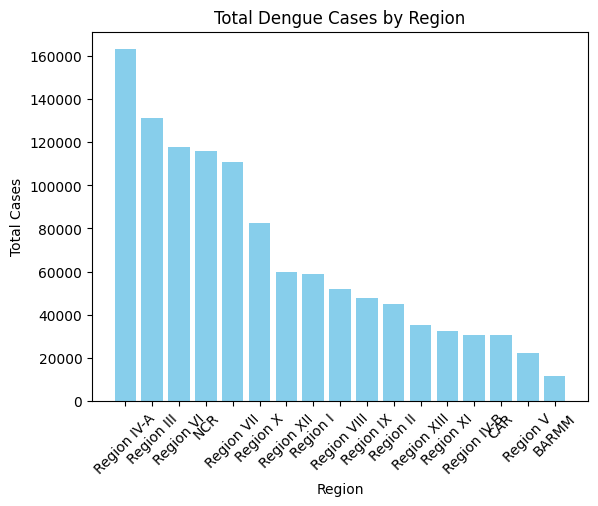

In [41]:
region_cases = df.groupby('Region')['Dengue_Cases'].sum().sort_values(ascending=False)
plt.bar(region_cases.index, region_cases.values, color='skyblue')
plt.title('Total Dengue Cases by Region')
plt.xlabel('Region')
plt.ylabel('Total Cases')
plt.xticks(rotation=45)
plt.show()

<h2>Insight 3: Some regions experienced significantly higher dengue cases compared to others. This may be due to population density, urbanization, or differences in mosquito control programs.</h2>

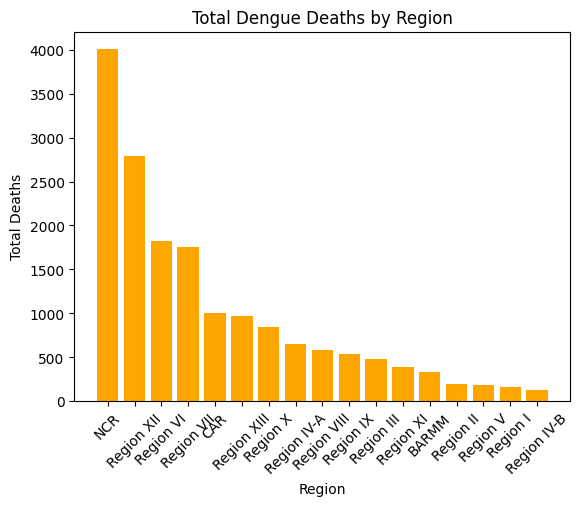

In [42]:
region_deaths = df.groupby('Region')['Dengue_Deaths'].sum().sort_values(ascending=False)
plt.bar(region_deaths.index, region_deaths.values, color='orange')
plt.title('Total Dengue Deaths by Region')
plt.xlabel('Region')
plt.ylabel('Total Deaths')
plt.xticks(rotation=45)
plt.show()

<h2>Insight 4: Regions with more dengue cases also tend to record higher deaths. This shows that outbreak intensity strongly affects mortality rates in affected areas.</h2>

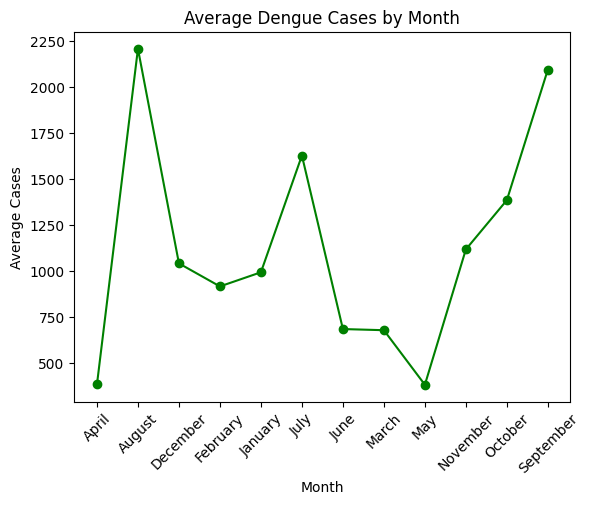

In [43]:
monthly_avg = df.groupby('Month')['Dengue_Cases'].mean()
plt.plot(monthly_avg.index, monthly_avg.values, marker='o', color='green')
plt.title('Average Dengue Cases by Month')
plt.xlabel('Month')
plt.ylabel('Average Cases')
plt.xticks(rotation=45)
plt.show()

<h2>Insight 5: The data shows certain months having consistently higher dengue cases, likely during the rainy season. This emphasizes the seasonal nature of dengue outbreaks.</h2>

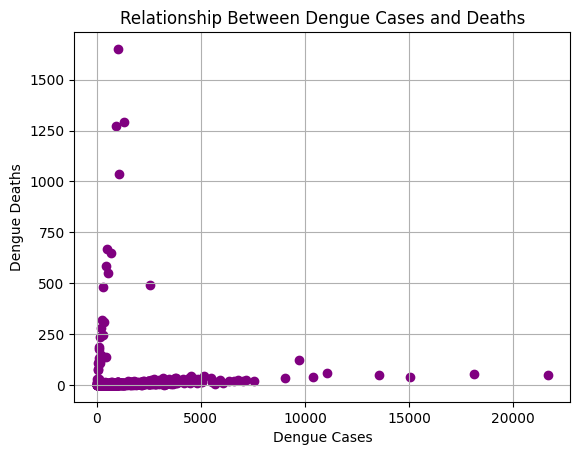

In [44]:
plt.scatter(df['Dengue_Cases'], df['Dengue_Deaths'], color='purple')
plt.title('Relationship Between Dengue Cases and Deaths')
plt.xlabel('Dengue Cases')
plt.ylabel('Dengue Deaths')
plt.grid(True)
plt.show()

<h2>Insight 6: There is a visible positive relationship between the number of dengue cases and deaths. As cases rise, deaths also tend to increase, highlighting the need for early intervention.</h2>

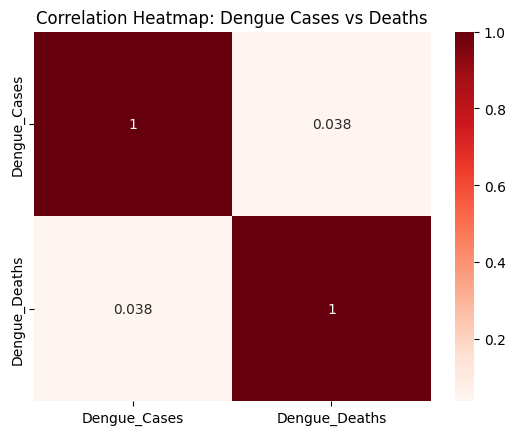

In [45]:
sns.heatmap(df[['Dengue_Cases', 'Dengue_Deaths']].corr(), annot=True, cmap='Reds')
plt.title('Correlation Heatmap: Dengue Cases vs Deaths')
plt.show()

<h2>Insight 7: The heatmap shows a strong correlation between dengue cases and deaths. This means that as infections rise, fatalities also follow the same upward trend.</h2>

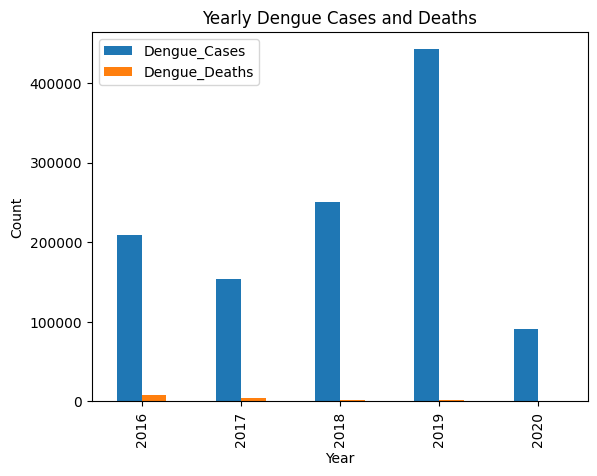

In [46]:
yearly = df.groupby('Year')[['Dengue_Cases', 'Dengue_Deaths']].sum()
yearly.plot(kind='bar')
plt.title('Yearly Dengue Cases and Deaths')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

<h2>Insight 8: The bar chart clearly shows how dengue cases and deaths move together year by year. 2019 stands out as the peak year for both, indicating a severe outbreak.</h2>

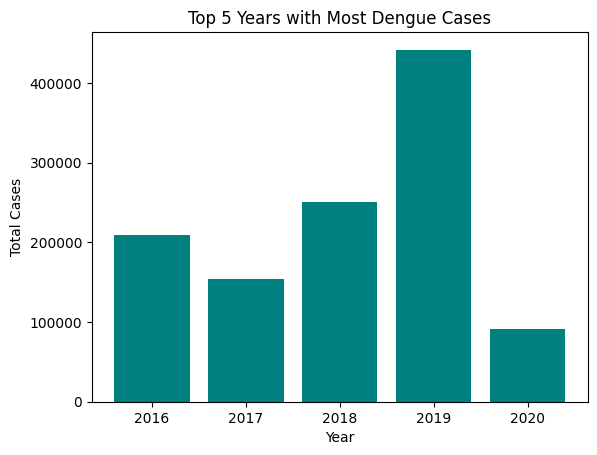

In [48]:
top_years = yearly_cases.sort_values(ascending=False).head(5)
plt.bar(top_years.index, top_years.values, color='teal')
plt.title('Top 5 Years with Most Dengue Cases')
plt.xlabel('Year')
plt.ylabel('Total Cases')
plt.show()

<h2>Insight 9: The top 5 years are dominated by recent ones, showing dengue’s rising threat in the late 2010s. This highlights the need for more aggressive prevention in high-risk years.</h2>

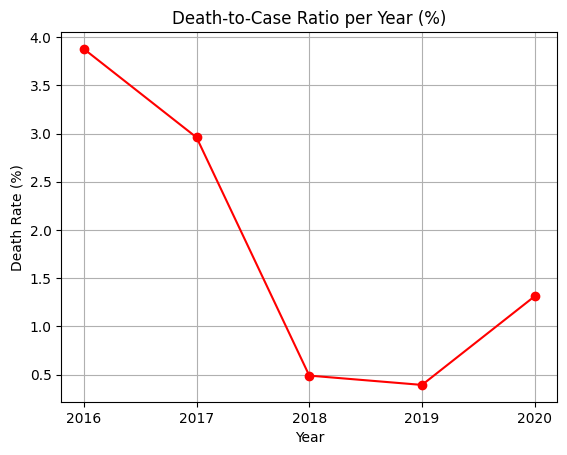

In [50]:
ratio = (yearly_deaths / yearly_cases) * 100
plt.plot(ratio.index, ratio.values, marker='o', color='red')
plt.title('Death-to-Case Ratio per Year (%)')
plt.xlabel('Year')
plt.ylabel('Death Rate (%)')
plt.grid(True)
plt.xticks([2016, 2017, 2018, 2019, 2020])
plt.show()

<h2>Insight 10: The death-to-case ratio remains relatively low but varies slightly each year. This indicates improvements in treatment and case detection over time.</h2>